# Exploração das funções de `analytics/` sem MCP

Demonstra o uso direto do módulo de analytics — sem passar pelo servidor MCP — contra o banco SQLite local (`data/strava.db`). Cada célula carrega dados brutos via SQL e usa as mesmas funções consumidas pelas tools MCP.

> Pré-requisito: `uv sync --group notebook` e ter rodado `strava-mcp setup`, `sync --full --streams` e `compute-metrics`.

## 1. Setup

In [1]:
import sqlite3
from datetime import date, timedelta

import matplotlib.pyplot as plt
import pandas as pd

DB = "../data/strava.db"
conn = sqlite3.connect(DB)
print(f"Atividades no banco: {pd.read_sql('SELECT COUNT(*) AS n FROM activities', conn)['n'][0]}")

Atividades no banco: 300


## 2. Visão geral das atividades recentes

Carrega as últimas 60 atividades e mostra distância semanal nos últimos 90 dias.

In [2]:
activities = pd.read_sql(
    """SELECT id, name, sport_type, start_date_utc, distance_m, moving_time_s,
              average_heartrate, average_speed_mps
       FROM activities
       ORDER BY start_date_utc DESC
       LIMIT 60""",
    conn,
)
activities["start"] = pd.to_datetime(activities["start_date_utc"], utc=True).dt.tz_localize(None)
activities["distance_km"] = activities["distance_m"] / 1000
activities["pace_min_per_km"] = (1000 / activities["average_speed_mps"]) / 60
activities[["name", "sport_type", "start", "distance_km", "pace_min_per_km", "average_heartrate"]].head(10)

,name,sport_type,start,distance_km,pace_min_per_km,average_heartrate
0,Morning Run,Run,2026-05-09 10:35:39,16.0167,5.391998,160.0
1,Evening Weight Training,WeightTraining,2026-05-07 22:06:23,0.0000,inf,107.2
2,Evening Run,Run,2026-05-06 22:17:45,12.0127,5.441288,147.0
3,Evening Weight Training,WeightTraining,2026-05-05 22:08:56,0.0000,inf,103.3
4,Evening Run,Run,2026-05-04 22:15:53,10.5936,6.014676,145.2
5,Morning Weight Training,WeightTraining,2026-05-03 11:21:24,0.0000,inf,124.3
6,Morning Run,Run,2026-05-02 12:29:28,12.0330,5.500550,174.7
7,Evening Weight Training,WeightTraining,2026-04-30 22:32:31,0.0000,inf,118.1
8,Evening Run,Run,2026-04-30 21:15:45,10.0414,5.978001,148.6
9,Evening Run,Run,2026-04-29 22:17:04,10.2142,5.885122,145.6


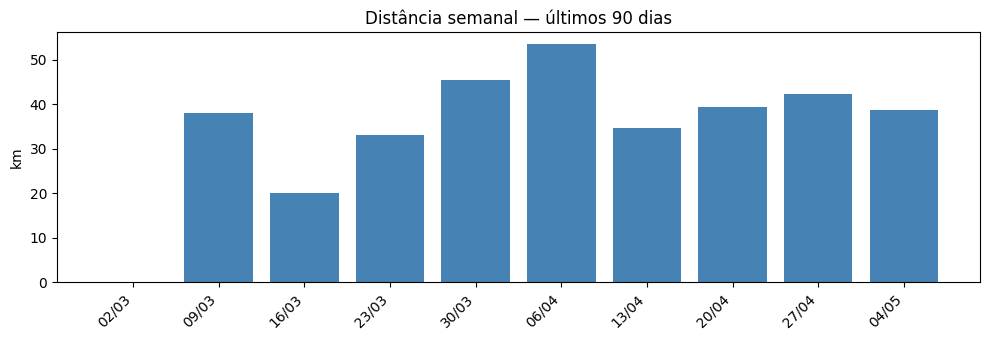

In [3]:
cutoff = pd.Timestamp.now() - pd.Timedelta(days=90)
recent = activities[activities["start"] >= cutoff].copy()
recent["week"] = recent["start"].dt.to_period("W").dt.start_time
weekly_km = recent.groupby("week")["distance_km"].sum().sort_index()

labels = [d.strftime("%d/%m") for d in weekly_km.index]
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(range(len(weekly_km)), weekly_km.values, color="steelblue")
ax.set_xticks(range(len(weekly_km)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_ylabel("km")
ax.set_title("Distância semanal — últimos 90 dias")
plt.tight_layout()
plt.show()

## 3. CTL / ATL / TSB — evolução de carga e forma

Lê `daily_metrics` (já populado por `compute-metrics`) e plota os últimos 180 dias. TSB > 5 indica frescor (race-ready); TSB < -10 indica fadiga acumulada.

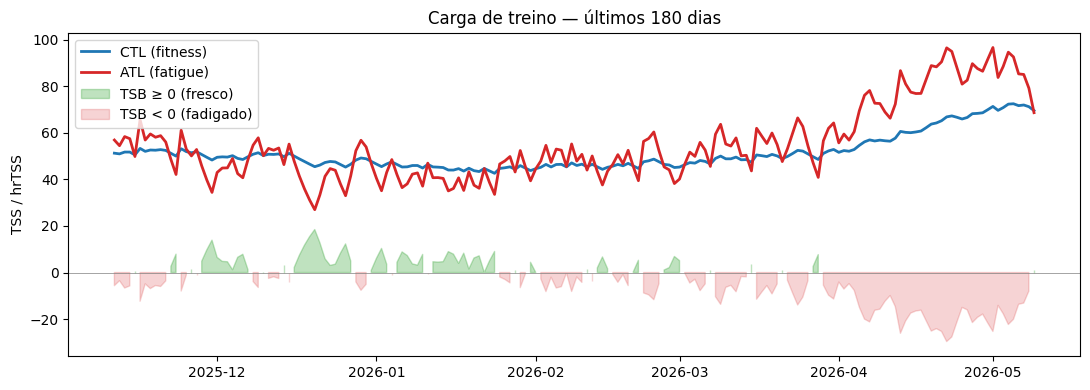


Hoje (2026-05-09): CTL=69.5, ATL=68.6, TSB=0.9 → productive


In [4]:
from strava_mcp.analytics.load import tsb_interpretation

daily = pd.read_sql(
    """SELECT date, daily_tss, ctl, atl, tsb
       FROM daily_metrics
       ORDER BY date DESC
       LIMIT 180""",
    conn,
    parse_dates=["date"],
).sort_values("date")

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(daily["date"], daily["ctl"], label="CTL (fitness)", color="#1f77b4", linewidth=2)
ax.plot(daily["date"], daily["atl"], label="ATL (fatigue)", color="#d62728", linewidth=2)
ax.fill_between(daily["date"], daily["tsb"], 0, where=(daily["tsb"] >= 0),
                color="#2ca02c", alpha=0.3, label="TSB ≥ 0 (fresco)")
ax.fill_between(daily["date"], daily["tsb"], 0, where=(daily["tsb"] < 0),
                color="#d62728", alpha=0.2, label="TSB < 0 (fadigado)")
ax.axhline(0, color="grey", linewidth=0.5)
ax.set_title("Carga de treino — últimos 180 dias")
ax.set_ylabel("TSS / hrTSS")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

current = daily.iloc[-1]
print(
    f"\nHoje ({current['date'].date()}): "
    f"CTL={current['ctl']:.1f}, ATL={current['atl']:.1f}, "
    f"TSB={current['tsb']:.1f} → {tsb_interpretation(current['tsb'])}"
)

## 4. Eficiência aeróbica por mês

EF = NGP / FCméd. Tendência crescente em runs de Z2 sugere ganho de capacidade aeróbica. Aqui agrupamos por mês e mostramos só corridas com EF computado (depende dos streams).

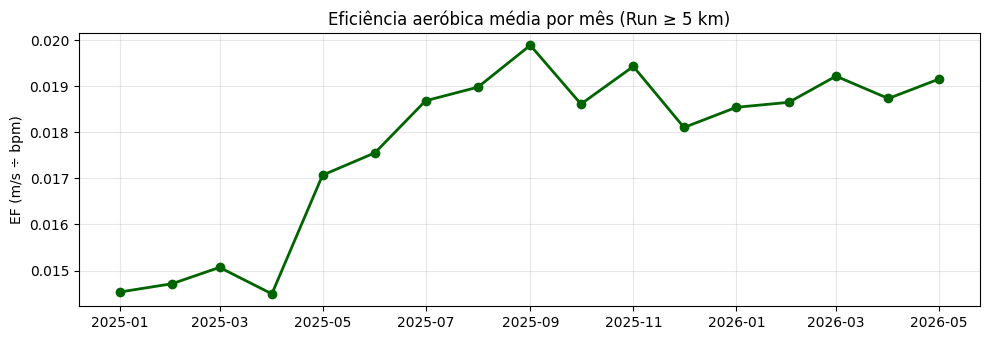

Meses cobertos: 17, último valor: 0.01915


In [5]:
ef = pd.read_sql(
    """SELECT a.start_date_utc, m.aerobic_efficiency, a.distance_m
       FROM activity_metrics m
       JOIN activities a ON a.id = m.activity_id
       WHERE a.sport_type IN ('Run', 'TrailRun')
         AND m.aerobic_efficiency IS NOT NULL
         AND a.distance_m >= 5000
       ORDER BY a.start_date_utc""",
    conn,
)
ef["start"] = pd.to_datetime(ef["start_date_utc"], utc=True).dt.tz_localize(None)
ef["month"] = ef["start"].dt.to_period("M").dt.start_time
monthly_ef = ef.groupby("month")["aerobic_efficiency"].mean().sort_index()

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(monthly_ef.index, monthly_ef.values, marker="o", color="darkgreen", linewidth=2)
ax.set_title("Eficiência aeróbica média por mês (Run ≥ 5 km)")
ax.set_ylabel("EF (m/s ÷ bpm)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Meses cobertos: {len(monthly_ef)}, último valor: {monthly_ef.iloc[-1]:.5f}")

## 5. Predição de tempo de prova (Riegel + VDOT)

Pega o melhor 21 km do histórico e projeta tempo para a maratona usando os dois modelos. VDOT é tipicamente mais conservador.

In [6]:
from strava_mcp.analytics.predictions import predict_race_time

best_half = pd.read_sql(
    """SELECT id, name, start_date_utc, distance_m, moving_time_s
       FROM activities
       WHERE sport_type IN ('Run', 'TrailRun')
         AND distance_m BETWEEN 20500 AND 21500
       ORDER BY moving_time_s ASC
       LIMIT 1""",
    conn,
    parse_dates=["start_date_utc"],
).iloc[0]

print(f"Melhor 21 km: {best_half['name']} — "
      f"{best_half['distance_m']/1000:.2f} km em {best_half['moving_time_s']/60:.1f} min")

predictions = predict_race_time(
    known_distance_m=float(best_half["distance_m"]),
    known_time_s=int(best_half["moving_time_s"]),
    target_distance_m=42195.0,
)


def fmt(seconds: float) -> str:
    h, rem = divmod(int(seconds), 3600)
    m, s = divmod(rem, 60)
    return f"{h:01d}:{m:02d}:{s:02d}"


print("\nPredição para maratona (42,195 km):")
if predictions.get("riegel"):
    r = predictions["riegel"]
    print(f"  Riegel: {fmt(r['time_s'])} ({r['pace_min_per_km']:.2f} min/km)")
if predictions.get("vdot"):
    v = predictions["vdot"]
    print(f"  VDOT:   {fmt(v['time_s'])} ({v['pace_min_per_km']:.2f} min/km, "
          f"VDOT={v['vdot_score']:.1f})")

Melhor 21 km: Mizuno Athenas Run Faster — 21.22 km em 100.2 min

Predição para maratona (42,195 km):
  Riegel: 3:27:33 (4.92 min/km)
  VDOT:   3:26:51 (4.90 min/km, VDOT=45.4)


## 6. Distribuição por zona — últimas 12 semanas

Soma `z1_seconds`..`z5_seconds` em todas as runs do período e mostra a polarização. Idealmente em base aeróbica: Z1+Z2 > 75%, Z4+Z5 < 15%.

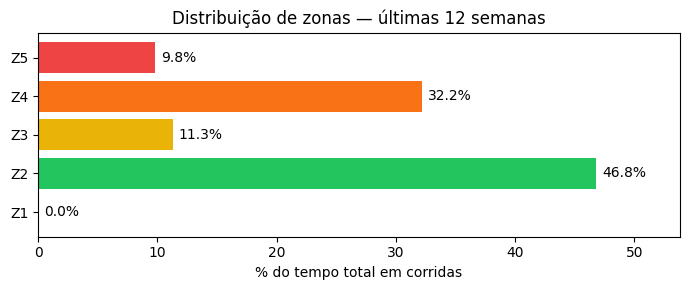


Z1+Z2 (aeróbico): 46.8% | Z4+Z5 (alta intensidade): 42.0%


In [7]:
zones = pd.read_sql(
    """SELECT SUM(m.z1_seconds) AS z1, SUM(m.z2_seconds) AS z2,
              SUM(m.z3_seconds) AS z3, SUM(m.z4_seconds) AS z4,
              SUM(m.z5_seconds) AS z5
       FROM activity_metrics m
       JOIN activities a ON a.id = m.activity_id
       WHERE a.sport_type IN ('Run', 'TrailRun')
         AND a.start_date_utc >= date('now', '-84 days')""",
    conn,
).iloc[0]
total = zones.sum()
pct = (zones / total * 100).round(1)

fig, ax = plt.subplots(figsize=(7, 3))
colors = ["#3b82f6", "#22c55e", "#eab308", "#f97316", "#ef4444"]
ax.barh(["Z1", "Z2", "Z3", "Z4", "Z5"], pct.values, color=colors)
for i, v in enumerate(pct.values):
    ax.text(v + 0.5, i, f"{v}%", va="center")
ax.set_xlim(0, max(pct.values) * 1.15)
ax.set_title("Distribuição de zonas — últimas 12 semanas")
ax.set_xlabel("% do tempo total em corridas")
plt.tight_layout()
plt.show()

print(f"\nZ1+Z2 (aeróbico): {pct['z1'] + pct['z2']:.1f}% | "
      f"Z4+Z5 (alta intensidade): {pct['z4'] + pct['z5']:.1f}%")

In [8]:
conn.close()